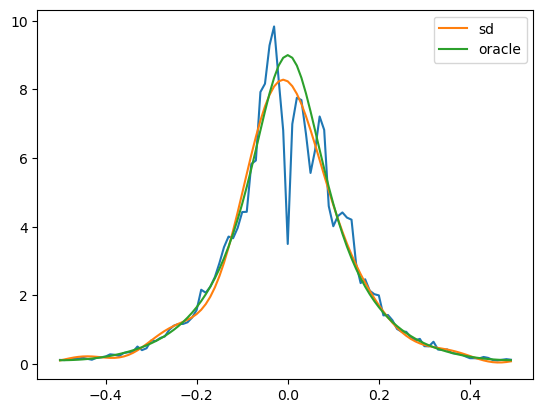

In [2]:
from statsmodels.tsa.arima_process import arma_generate_sample
import numpy as np
import sys

import sys

sys.path.append(
    "/Users/alexisrosuel/Library/Mobile Documents/com~apple~CloudDocs/recherche/CLT-LSS-coherence/src"
)

from gpy_test.lag_window import lag_window
from clt_lss_coherence.data import ARMA_spectral_density

from scipy.signal import periodogram

from scipy.signal import welch
import matplotlib.pyplot as plt

sys.path.append(
    "/Users/alexisrosuel/Library/Mobile Documents/com~apple~CloudDocs/recherche/spectral-coherence/src"
)
sys.path.append(
    "/Users/alexisrosuel/Library/Mobile Documents/com~apple~CloudDocs/recherche/CLT-LSS-coherence/src"
)


# generate a multi-dimensional time series. Each series is an ARMA(1,1) process, independent with the other time series.
M = 50  # dimension of the time series
N = 100  # number of samples

# Generate an ARMA time series. By assumption it must be the same for all the time series in order to use the GPY test.
ar = 0.5
ma = 0.5
real = arma_generate_sample([1, -ar], [1, ma], (N, M), scale=1 / np.sqrt(2))
imag = arma_generate_sample([1, -ar], [1, ma], (N, M), scale=1 / np.sqrt(2))
y = real + 1j * imag

frequency_grid, sd_values = periodogram(
    y.T[0], scaling="density", return_onesided=False
)

all_sd = lag_window(y, L=5)
sd = lambda nu: np.mean(all_sd(nu))
sd_oracle = ARMA_spectral_density(ar, ma)

(frequency_grid, sd_values) = welch(
    y.T, scaling="density", nperseg=100, return_onesided=False
)
# recall the time series are assume to share the same spectral density
sd_values = np.mean(sd_values, axis=0)

frequency_grid = np.fft.fftshift(frequency_grid)
sd_values = np.fft.fftshift(sd_values, axes=0)

plt.plot(frequency_grid, sd_values)
plt.plot(frequency_grid, [sd(f) for f in frequency_grid], label="sd")
plt.plot(frequency_grid, [sd_oracle(f) for f in frequency_grid], label="oracle")
plt.legend();

In [1]:
ar = 0.1
ma = -0.1

import sys

sys.path.append(
    "/Users/alexisrosuel/Library/Mobile Documents/com~apple~CloudDocs/recherche/CLT-LSS-coherence/src"
)
from clt_lss_coherence.data import ARMA_spectral_density

oracle_sd = ARMA_spectral_density(ar, ma)